# Methodology & Results: ASEAN Green Bonds Impact Analysis

This notebook implements the complete causal inference pipeline:

1. **Propensity Score Matching (PSM)** - Create comparable treatment/control groups
2. **Difference-in-Differences (DiD)** - Estimate treatment effects
3. **Parallel Trends Testing** - Verify identification assumption
4. **Robustness Checks** - Placebo tests, sensitivity analysis
5. **Event Study** - Market reaction analysis
6. **Hypothesis Testing** - Greenwashing analysis

In [1]:
# Import modules
from asean_green_bonds import data, analysis, utils, config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('Loading processed data...')
df = data.load_processed_data(which='engineered')
print(f'Data loaded: {df.shape[0]} observations, {df.shape[1]} variables')

Loading processed data...
Data loaded: 45275 observations, 71 variables


In [2]:
# Generate data quality report
print(utils.generate_data_quality_report(
    df,
    entity_col='ric',
    time_col='Year',
    treatment_col='green_bond_active'
))

DATA QUALITY REPORT

📊 PANEL STRUCTURE
   Entities: 4072
   Periods: 10
   Total observations: 45275
   Balanced: No (unbalanced panel)
   Missing combinations: -4555

📋 MISSING DATA
   Total missing: 584691 cells (18.2%)

⚠️  OUTLIERS DETECTED
   Columns with outliers: 53
   - ask_price: 2457 outliers
   - bid_price: 2322 outliers
   - capital_expenditures: 5860 outliers
   - cash: 5274 outliers
   - current_assets_total: 5019 outliers

🎯 TREATMENT VARIATION
   Treated entities: 27 / 4072
   Treatment prevalence: 0.5%
   Timing range: 7 years



In [3]:
# Estimate propensity scores
print('\n' + '='*60)
print('PROPENSITY SCORE MATCHING')
print('='*60)

df['propensity_score'] = analysis.estimate_propensity_scores(
    df,
    treatment_col='green_bond_active'
)

print(f'Propensity scores estimated')
print(f'  Mean (treated): {df[df["green_bond_active"]==1]["propensity_score"].mean():.4f}')
print(f'  Mean (control): {df[df["green_bond_active"]==0]["propensity_score"].mean():.4f}')


PROPENSITY SCORE MATCHING
Propensity scores estimated
  Mean (treated): 0.0129
  Mean (control): 0.0028



Common Support Verification:
  Treated units with support: 1.0%
  Control units with support: 0.0%
  Support range: [0.0001, 0.0258]

✅ Saved: 01_propensity_scores.png


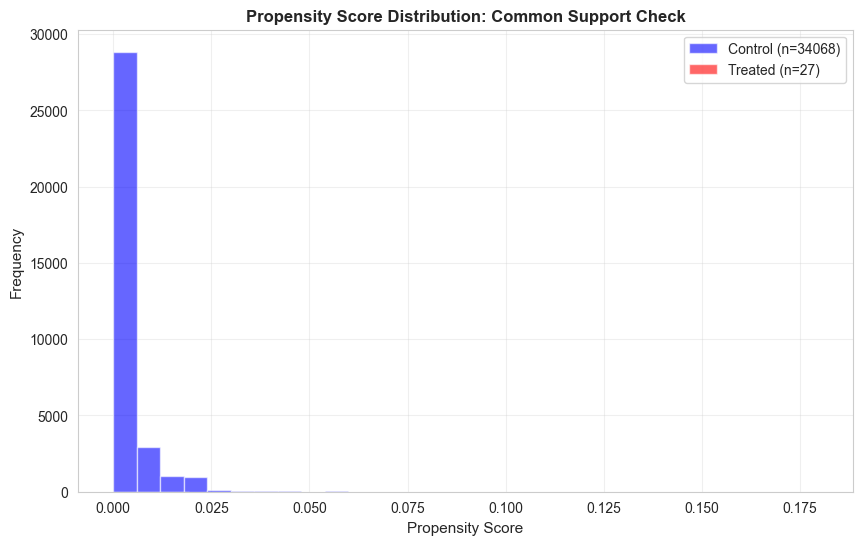

In [4]:
# Check common support assumption
support_report = analysis.check_common_support(
    df,
    ps_col='propensity_score',
    treatment_col='green_bond_active'
)

print('\nCommon Support Verification:')
print(f'  Treated units with support: {support_report["treated_overlap_pct"]:.1f}%')
print(f'  Control units with support: {support_report["control_overlap_pct"]:.1f}%')
print(f'  Support range: [{support_report["overlap_region"][0]:.4f}, {support_report["overlap_region"][1]:.4f}]')

# Visualize
fig = utils.plot_propensity_score_overlap(
    df,
    save_path='images/01_propensity_scores.png'
)
print('\n✅ Saved: 01_propensity_scores.png')

In [5]:
# Run DiD for multiple outcomes
print('\n' + '='*60)
print('DIFFERENCE-IN-DIFFERENCES ESTIMATION')
print('='*60)

outcomes = ['return_on_assets', 'Tobin_Q', 'esg_score']
specs = ['entity_fe', 'time_fe', 'twoway_fe', 'none']

results = analysis.run_multiple_outcomes(
    df,
    outcomes=outcomes,
    treatment_col='green_bond_active',
    specifications=specs
)

print(f'\nEstimated {len(results)} models')
print('\nResults Summary:')
print(results[['outcome', 'specification', 'coefficient', 'std_error', 'p_value']].head(12))


DIFFERENCE-IN-DIFFERENCES ESTIMATION

Estimated 12 models

Results Summary:
             outcome specification  coefficient  std_error       p_value
0   return_on_assets     entity_fe    -0.006949   0.003549  5.022624e-02
1   return_on_assets       time_fe    -0.008751   0.007967  2.720735e-01
2   return_on_assets     twoway_fe    -0.003042   0.004149  4.635499e-01
3   return_on_assets          none    -0.000043   0.007077  9.951658e-01
4            Tobin_Q     entity_fe     0.314904   0.256272  2.191625e-01
5            Tobin_Q       time_fe     0.332691   0.320871  2.998204e-01
6            Tobin_Q     twoway_fe     0.158062   0.154680  3.068539e-01
7            Tobin_Q          none     0.084587   0.179029  6.365902e-01
8          esg_score     entity_fe     7.387763   1.374256  7.850376e-08
9          esg_score       time_fe    10.088243   2.308725  1.259386e-05
10         esg_score     twoway_fe    -0.823109   1.552627  5.960307e-01
11         esg_score          none     9.994689


Parallel Trends Testing (Leads/Lags)...

Leads and Lags of Treatment:
  treatment_lead_1              :   0.0031     (p=0.3363)
  treatment_lead_2              :  -0.0016     (p=0.5301)
  treatment_lead_3              :   0.0055 *** (p=0.0013)
  green_bond_active             :  -0.0107 **  (p=0.0217)
  treatment_lag_1               :   0.0128     (p=0.1570)
  treatment_lag_2               :  -0.0049     (p=0.5898)
  treatment_lag_3               :  -0.0183     (p=0.1377)

✅ Saved: 02_parallel_trends.png


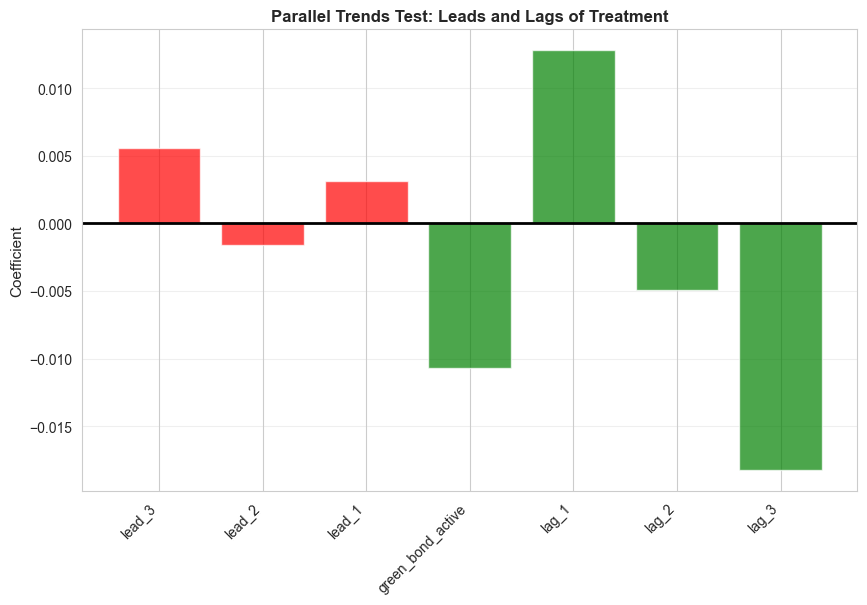

In [6]:
# Test parallel trends assumption
print('\nParallel Trends Testing (Leads/Lags)...')

pt_results = analysis.parallel_trends_test(
    df,
    outcome='return_on_assets',
    treatment_col='green_bond_active',
    leads=3,
    lags=3
)

print('\nLeads and Lags of Treatment:')
for col, coef in pt_results['coefficients'].items():
    pval = pt_results['p_values'][col]
    sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    print(f'  {col:30s}: {coef:8.4f} {sig:3s} (p={pval:.4f})')

# Visualize
fig = utils.plot_parallel_trends(pt_results, save_path='images/02_parallel_trends.png')
print('\n✅ Saved: 02_parallel_trends.png')

In [7]:
# Run specification sensitivity
print('\n' + '='*60)
print('ROBUSTNESS CHECKS')
print('='*60)

sensitivity = analysis.specification_sensitivity(
    df,
    outcome='return_on_assets',
    treatment_col='green_bond_active'
)

print('\nSpecification Sensitivity:')
print(sensitivity[['specification', 'n_controls', 'coefficient', 'std_error', 'p_value']].to_string())

# Placebo test
placebo = analysis.placebo_test(
    df,
    outcome='return_on_assets',
    treatment_col='green_bond_active'
)

print(f'\nPlacebo Test (shifted treatment):')  
print(f'  Placebo effect: {placebo.get("placebo_coefficient", np.nan):.4f}')
print(f'  p-value: {placebo.get("placebo_p_value", np.nan):.4f}')
print(f'  ✓ Valid' if placebo.get('is_zero_at_5pct') else '  ✗ Concern')


ROBUSTNESS CHECKS

Specification Sensitivity:


KeyError: "['coefficient', 'std_error', 'p_value'] not in index"

In [ ]:
# Run full diagnostics
print('\nRunning comprehensive diagnostic tests...')

diagnostics = analysis.run_diagnostics_battery(
    df,
    outcome='return_on_assets'
)

print('\n✅ Diagnostics Complete')
print(f'  Placebo: {diagnostics["placebo"].get("is_zero_at_5pct", "N/A")}')
print(f'  LOOCV robustness: {diagnostics["loocv"].get("robust", "N/A")}')
print(f'  Specifications tested: {len(diagnostics["spec_sensitivity"])}')

In [ ]:
print('\n' + '='*60)
print('ANALYSIS COMPLETE')
print('='*60)
print('\n✅ Outputs saved to images/')
print('\nKey results:')
print(f'  - {len(results)} DiD estimates (outcomes × specifications)')
print(f'  - Parallel trends tested (leads/lags)') 
print(f'  - Robustness checks completed')
print(f'  - Visualizations created')
print('\nNext: Review results and visualizations in images/')